<a href="https://colab.research.google.com/github/AndrewLoweUoM/NFM/blob/main/Data_Preparation_Checking_TS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Mount Drive

In [2]:
# Mount Drive
#from google.colab import drive
#drive.mount('/content/drive')

## Code Description:

This code performs a hydrological time-series workflow: loading 15-minute rainfall–flow data, exploring it, resampling to hourly and daily scales, visualising trends, and exporting processed datasets.

The script processes 15-minute rainfall and river flow time series data, then:

* Explores and visualises it
* Resamples it to hourly and daily scales
* Produces plots
* Exports processed datasets to CSV

## Code Description:

This code performs a hydrological time-series workflow: loading 15-minute rainfall–flow data, exploring it, resampling to hourly and daily scales, visualising trends, and exporting processed datasets.

The script processes 15-minute rainfall and river flow time series data, then:

* Explores and visualises it
* Resamples it to hourly and daily scales
* Produces plots
* Exports processed datasets to CSV

## Data Loading & Initial Exploration

* Reads a CSV file containing:
  * Date
  * Flow_m3s (river discharge)
  * Rain_mm (rainfall)
* Uses pandas for handling data.

Then:
* Displays first rows (df.head())
* Checks:
   * Data shape  
   * Column names
   * Missing values
  * Summary statistics (describe())

### Load Data (15 mins) and Create DataFrame ``` df ```



In [3]:
# Load the data using pandas
import pandas as pd # pandas for data manipulation
import matplotlib.pyplot as plt # import the pyplot module from matplotlib
from matplotlib.dates import DateFormatter
import numpy as np # numpy for numerical operations

# Load the all data
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Oak_s50_2023_2024.csv'
file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS.csv'
# Load the data
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS_before.csv'
# Load the data
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS_after.csv'

df = pd.read_csv(file_path)
# Displays start data in the Dataframe
df.head()

,Date,Flow_m3s,Rain_mm
0,29/01/2021 00:00,24.850,1.021
1,29/01/2021 00:15,24.657,1.017
2,29/01/2021 00:30,24.512,1.014
3,29/01/2021 00:45,24.369,1.011
4,29/01/2021 01:00,24.321,1.010


### Display DataFrame Dimensions, Check Missing Values, and Describe Statistics

In [4]:
# Displays DataFrame dimensions (rows and columns)
print('Shape of data:', df.shape)

Shape of data: (170909, 3)


In [5]:
# Displays all columnns in the DataFrame
print(df.columns)

Index(['Date', 'Flow_m3s', 'Rain_mm'], dtype='object')


In [6]:
# Check for missing values in the DataFrame
print(df.isnull().sum())

Date        0
Flow_m3s    0
Rain_mm     0
dtype: int64


In [7]:
#replace null values with 0
#df.fillna(0, inplace=True)
#df.fillna(method='ffill', inplace=True)

In [8]:
# Display summary statistics of the DataFrame
print(df.describe())

            Flow_m3s        Rain_mm
count  170909.000000  170909.000000
mean        4.411289       0.404151
std         4.397802       0.159674
min         0.660000       0.181000
25%         1.940000       0.294000
50%         2.881000       0.354000
75%         5.128000       0.467000
max        52.842000       1.496000


## Time Handling

* Converts Date column to datetime (dayfirst=True)
* Sets Date as DataFrame index

This enables time-based operations like resampling

### Set Date as the Index for the DataFrame

In [9]:
# Convert Date column to datetime objects using dayfirst=True
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Set Date as the index for the DataFrame
df.set_index('Date', inplace=True)

# Verify the change by checking the index type and first 5 rows
print('Index Type:', df.index.dtype)
print(df.head())

Index Type: datetime64[ns]
                     Flow_m3s  Rain_mm
Date                                  
2021-01-29 00:00:00    24.850    1.021
2021-01-29 00:15:00    24.657    1.017
2021-01-29 00:30:00    24.512    1.014
2021-01-29 00:45:00    24.369    1.011
2021-01-29 01:00:00    24.321    1.010


## Data Visualisation (15 minute)

### Plot Rainfall and Flow Timeseries (15 minutes)

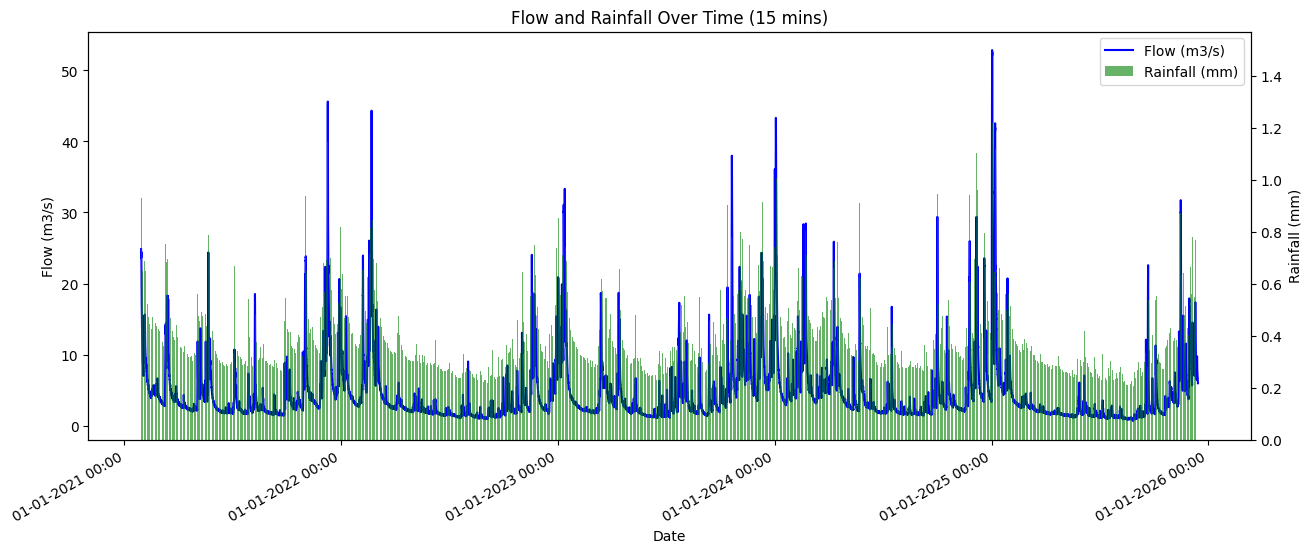

In [10]:
# Create a figure and a set of subplots for 15 minute data
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot 'Flow' on the first y-axis
ax1.plot(df.index, df['Flow_m3s'], color='blue', label='Flow (m3/s)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Flow (m3/s)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create a second y-axis
ax2 = ax1.twinx()
# Plot 'Rain' on the second y-axis as bars
ax2.bar(df.index, df['Rain_mm'], color='green', alpha=0.6, label='Rainfall (mm)', width=pd.Timedelta(minutes=10))
ax2.set_ylabel('Rainfall (mm)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Set title and add legends
plt.title('Flow and Rainfall Over Time (15 mins)')
fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

# Set x-axis date format to show full date and time
date_form = DateFormatter('%d-%m-%Y %H:%M')
ax1.xaxis.set_major_formatter(date_form)

# Improve date formatting on x-axis
fig.autofmt_xdate()

plt.show()

# Resampling to Hourly Data

### Data Loading & Time Handling

In [11]:
# Load the data using pandas
import pandas as pd # pandas for data manipulation
import matplotlib.pyplot as plt # import the pyplot module from matplotlib
from matplotlib.dates import DateFormatter
import numpy as np # numpy for numerical operations

# Load the all data to ensure 'df' is defined
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Oak_s50_2023_2024.csv'
file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS.csv'
# Load the all data to ensure 'df' is defined
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS_before.csv'
# Load the all data to ensure 'df' is defined
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS_after.csv'

df = pd.read_csv(file_path)

# Convert Date column to datetime objects using dayfirst=True
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Set Date as the index for the DataFrame
df.set_index('Date', inplace=True)

# Verify the change by checking the index type and first 5 rows
print('Index Type:', df.index.dtype)
print(df.head())

Index Type: datetime64[ns]
                     Flow_m3s  Rain_mm
Date                                  
2021-01-29 00:00:00    24.850    1.021
2021-01-29 00:15:00    24.657    1.017
2021-01-29 00:30:00    24.512    1.014
2021-01-29 00:45:00    24.369    1.011
2021-01-29 01:00:00    24.321    1.010


### Resamples 15 min Data to Hourly frequency to DataFrame ``` df_hourly ```



In [12]:
# Resample the 15-minute data to hourly frequency
# Flow_m3s is averaged (mean) and Rain_mm is totaled (sum) for each hour
df_hourly = df.resample('h').agg({
    'Flow_m3s': 'mean',
    'Rain_mm': 'sum'
})

# Print the shape of the new hourly dataset
print('Shape of hourly data:', df_hourly.shape)

# Display the first few rows of the resampled data
df_hourly.head()

Shape of hourly data: (42728, 2)


,Flow_m3s,Rain_mm
Date,,
2021-01-29 00:00:00,24.59700,4.063
2021-01-29 01:00:00,24.14200,4.025
2021-01-29 02:00:00,23.85675,4.001
2021-01-29 03:00:00,23.64425,3.983
2021-01-29 04:00:00,23.70300,3.988


### Check Missing Values

In [13]:
# Check missing Values
print(df_hourly.isnull().sum())

Flow_m3s    0
Rain_mm     0
dtype: int64


In [14]:
print (df_hourly)

                     Flow_m3s  Rain_mm
Date                                  
2021-01-29 00:00:00  24.59700    4.063
2021-01-29 01:00:00  24.14200    4.025
2021-01-29 02:00:00  23.85675    4.001
2021-01-29 03:00:00  23.64425    3.983
2021-01-29 04:00:00  23.70300    3.988
...                       ...      ...
2025-12-14 03:00:00   6.16975    2.044
2025-12-14 04:00:00   6.15125    2.041
2025-12-14 05:00:00   6.07725    2.029
2025-12-14 06:00:00   6.01600    2.019
2025-12-14 07:00:00   5.97300    0.503

[42728 rows x 2 columns]


## Data Visualisation (Hourly)

### Plot Rainfall and Flow Timeseries (Hourly)

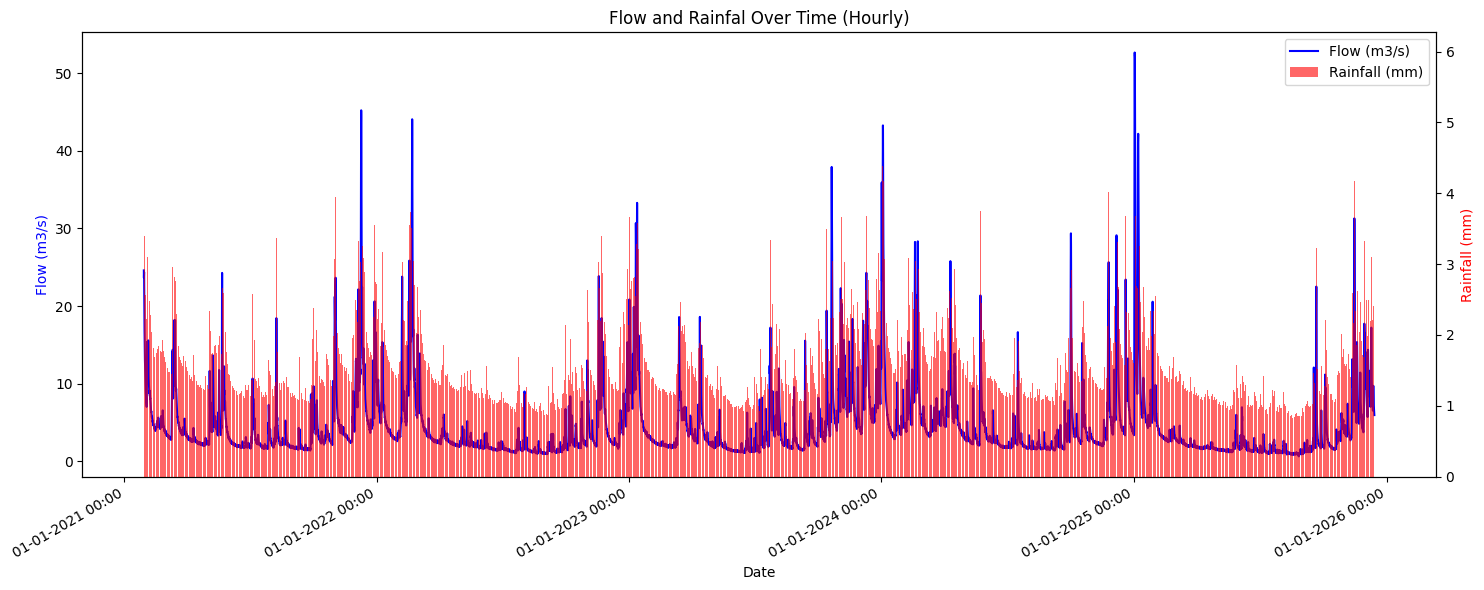

In [15]:
# Create a figure and a set of subplots for hourly data
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot 'Flow_m3s' on the primary y-axis (ax1)
line1, = ax1.plot(df_hourly.index, df_hourly['Flow_m3s'], color='blue', label='Flow (m3/s)')

# Create a secondary y-axis (ax2)
ax2 = ax1.twinx()

# Plot 'Rain_mm' on the secondary y-axis (ax2) as bars
# Using pd.Timedelta(hours=0.8) for better alignment in hourly frequency
bars1 = ax2.bar(df_hourly.index, df_hourly['Rain_mm'], color='red', alpha=0.6, label='Rainfall (mm)', width=pd.Timedelta(hours=0.8))

# Set labels
ax1.set_xlabel('Date')
ax1.set_ylabel('Flow (m3/s)', color='blue')
ax2.set_ylabel('Rainfall (mm)', color='red')

# Format x-axis
date_form = DateFormatter('%d-%m-%Y %H:%M')
ax1.xaxis.set_major_formatter(date_form)
fig.autofmt_xdate()

# Add title and combined legend
plt.title('Flow and Rainfal Over Time (Hourly)')
lines = [line1, bars1]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

# Show plot
plt.tight_layout()
plt.show()

### Output Timeseries (hourly) CSV file

In [16]:
# Define the all hourly timeseries output file path
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Oak_s50_2023_2024_hourly.csv'
final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_hourly.csv'
# Define the before NFM hourly timeseries output file path
# final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_hourly_before.csv'
# Define the after NFM hourly timeseries output file path
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_hourly_after.csv'

# Save the df_hourly to CSV
df_hourly.to_csv(final_output_path)

print(f'Successfully saved event adjusted results to: {final_output_path}')

Successfully saved event adjusted results to: /content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_hourly.csv


# Rasampling to Daily Data

## Data Loading & Time Handling

In [17]:
# Load the data using pandas
import pandas as pd # pandas for data manipulation
import matplotlib.pyplot as plt # import the pyplot module from matplotlib
from matplotlib.dates import DateFormatter
import numpy as np # numpy for numerical operations

# Load the all data to ensure 'df' is defined
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Oak_s50_2023_2024.csv'
file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS.csv'
# Load the before NFM data to ensure 'df' is defined
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS_before.csv'
# Load the all data to ensure 'df' is defined
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS_after.csv'

df = pd.read_csv(file_path)

# Convert Date column to datetime objects using dayfirst=True
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Set Date as the index for the DataFrame
df.set_index('Date', inplace=True)

# Verify the change by checking the index type and first 5 rows
print('Index Type:', df.index.dtype)
print(df.head())

Index Type: datetime64[ns]
                     Flow_m3s  Rain_mm
Date                                  
2021-01-29 00:00:00    24.850    1.021
2021-01-29 00:15:00    24.657    1.017
2021-01-29 00:30:00    24.512    1.014
2021-01-29 00:45:00    24.369    1.011
2021-01-29 01:00:00    24.321    1.010


### Resample to Daily frequency to DataFrame ``` df_daily ```



In [18]:
# Resample the 15-minute data to daily frequency
# Flow_m3s is averaged (mean) and Rain_mm is totaled (sum) for each hour
df_daily = df.resample('D').agg({
    'Flow_m3s': 'mean',
    'Rain_mm': 'sum'
})

# Print the shape of the new daily dataset
print('Shape of daily data:', df_daily.shape)

# Display the first few rows of the resampled data
df_daily.head()

Shape of daily data: (1781, 2)


,Flow_m3s,Rain_mm
Date,,
2021-01-29,21.860875,91.741
2021-01-30,13.824458,72.950
2021-01-31,9.744073,61.351
2021-02-01,7.818292,55.069
2021-02-02,11.542990,66.109


### Check Missing Values

In [19]:
# Check missing Values
print(df_daily.isnull().sum())

Flow_m3s    0
Rain_mm     0
dtype: int64


In [20]:
print (df_daily)

             Flow_m3s  Rain_mm
Date                          
2021-01-29  21.860875   91.741
2021-01-30  13.824458   72.950
2021-01-31   9.744073   61.351
2021-02-01   7.818292   55.069
2021-02-02  11.542990   66.109
...               ...      ...
2025-12-10  11.783573   67.186
2025-12-11   7.606427   54.313
2025-12-12   7.975656   55.490
2025-12-13   7.320521   53.283
2025-12-14   6.192552   14.845

[1781 rows x 2 columns]


## Data Visualisation (Daily)

### Plot Rainfall and Flow Timeseries (Daily)

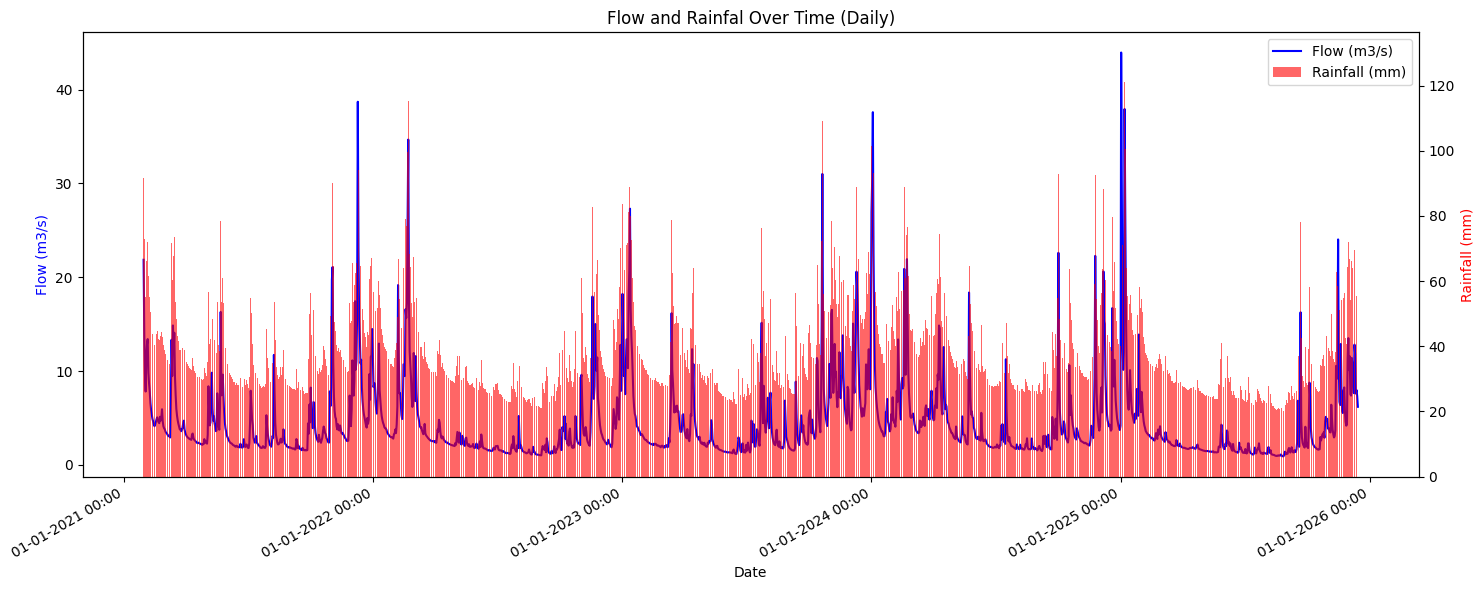

In [21]:
# Create a figure and a set of subplots for daily data
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot 'Flow_m3s' on the primary y-axis (ax1)
line1, = ax1.plot(df_daily.index, df_daily['Flow_m3s'], color='blue', label='Flow (m3/s)')

# Create a secondary y-axis (ax2)
ax2 = ax1.twinx()

# Plot 'Rain_mm' on the secondary y-axis (ax2) as bars
bars1 = ax2.bar(df_daily.index, df_daily['Rain_mm'], color='red', alpha=0.6, label='Rainfall (mm)', width=0.8)

# Set labels
ax1.set_xlabel('Date')
ax1.set_ylabel('Flow (m3/s)', color='blue')
ax2.set_ylabel('Rainfall (mm)', color='red')

# Format x-axis
date_form = DateFormatter('%d-%m-%Y %H:%M')
ax1.xaxis.set_major_formatter(date_form)
fig.autofmt_xdate()

# Add title and combined legend
plt.title('Flow and Rainfal Over Time (Daily)')
lines = [line1, bars1]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

# Show plot
plt.tight_layout()
plt.show()

### Output Timeseries (daily) CSV file



In [22]:
# Define all daily timeseries output file path
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Oak_s50_2023_2024_daily.csv'
final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_daily.csv'
# Define the daily timeseries output file path
# final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_daily_before.csv'
# Define the daily timeseries output file path
# final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_daily_after.csv'

# Save the df_daily to CSV
df_daily.to_csv(final_output_path)

print(f'Successfully saved event adjusted results to: {final_output_path}')

Successfully saved event adjusted results to: /content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_daily.csv
